In [1]:
from ddgs import DDGS
from fastcore.all import *
from fastdownload import download_url
from fastai.vision.all import *

In [2]:
def search_images(keywords, max_images=200):
    return L(DDGS().images(keywords, max_results=max_images)).itemgot('image')

In [3]:
urls = search_images('bird photos', max_images=1)
urls[0]

'https://images.pexels.com/photos/326900/pexels-photo-326900.jpeg?cs=srgb&dl=wood-flight-bird-326900.jpg&fm=jpg'

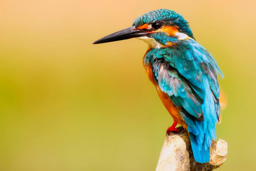

In [4]:
dest = 'bird.jpg'
download_url(urls[0], dest)

im = Image.open(dest)
im.to_thumb(256, 256)


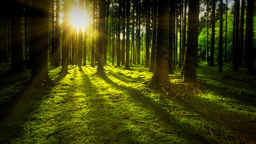

In [5]:
forest_urls = search_images('forest photos', max_images=1)
forest_dest = 'forest.jpg'
download_url(forest_urls[0], forest_dest)

Image.open(forest_dest).to_thumb(256, 256)

In [6]:
searches = 'bird', 'forest'
path = Path('images')

In [ ]:
for search in searches:
    dest = (path/search)
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{search} photos'))
    time.sleep(5)
    resize_images(dest, max_size=400, dest=dest)

In [7]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

0

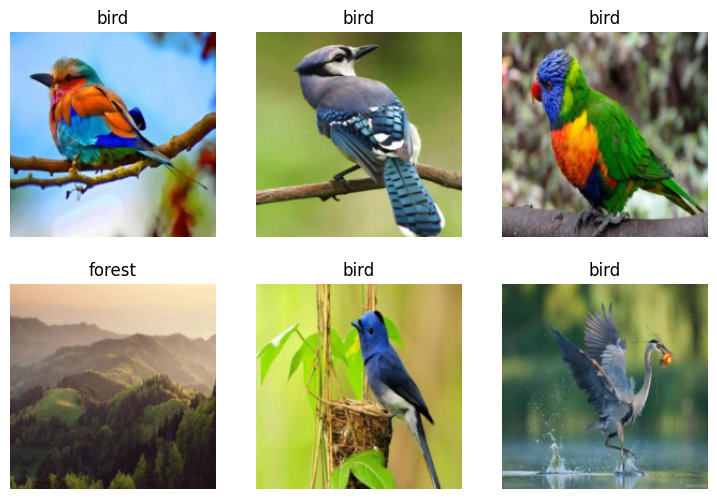

In [8]:
dls = DataBlock(
    blocks = (ImageBlock, CategoryBlock),
    get_items = get_image_files,
    splitter = RandomSplitter(valid_pct=0.2, seed=42),
    get_y = parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch(max_n=6)

In [9]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,0.536405,0.009946,0.000000,00:16


epoch,train_loss,valid_loss,error_rate,time
0,0.006036,0.000241,0.000000,00:18
1,0.003932,0.000285,0.000000,00:18
2,0.011203,0.000122,0.000000,00:18


In [13]:
is_bird,_,probs = learn.predict(PILImage.create(dest))
print(f'Is a bird: {is_bird}; Probability: {probs[0]:.4f}')

Is a bird: bird; Probability: 1.0000


In [14]:
is_bird,_,probs = learn.predict(PILImage.create(forest_dest))
print(f'Is a bird: {is_bird}; Probability: {probs[1]:.4f}')

Is a bird: forest; Probability: 1.0000
